Supervised Learning

Linear Regression

In [109]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsClassifier

In [110]:
data=pd.read_csv("Boston.csv")

In [111]:
data.head()

,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [112]:
x=data.iloc[:,:12].values
y=data.iloc[:,12].values

In [78]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [79]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [80]:
model.coef_

array([-1.25156811e-01,  4.48575121e-02,  2.01265385e-02, -1.62895522e+01,
        3.77366409e+00, -2.13185120e-03, -1.40611846e+00,  2.66835482e-01,
       -1.21692284e-02, -1.07660161e+00,  8.72533635e-03, -4.94425348e-01])

In [81]:
model.intercept_

np.float64(38.42706211257687)

In [82]:
model.score(x_train,y_train)

0.7690953567794605

In [83]:
model.score(x_train,y_train)*100

76.90953567794605

In [84]:
y_pred=model.predict(x_test)

In [85]:
MSE=mean_squared_error(y_pred,y_test)

In [86]:
MSE

34.21225254753343

In [87]:
RMSE=np.sqrt(MSE)
RMSE

np.float64(5.849124083786685)

In [88]:
x1=np.array([[0.00732,16.0,2.31,0.598,8.575,65.2,4.0800,1,236,17.3,396.90,4.98],[0.00932,12.0,3.31,0.498,6.575,67.2,5.0800,1,266,15.3,396.90,4.98
]])

In [89]:
model.predict(x1)

array([35.70295324, 30.00277067])

In [90]:
x2=np.array([0.00732,16.0,2.31,0.598,8.575,65.2,4.0800,1,236,17.3,396.90,4.98]).reshape(1,12)

In [91]:
model.predict(x2)

array([35.70295324])

Categorical Independent Variables

In [92]:
data=pd.read_csv("GPA_data.CSV")

In [93]:
data.head()

,ID,Gender,Age,Extra_Curricular,Study_Hours,Annual_Income,Distance_From_Home,GPA
0,8867,Male,22,Societies,10,1318792,154,1.76
1,1316,Female,24,Societies,9,874657,181,3.88
2,9443,Male,22,Societies,15,1098331,94,1.73
3,1829,Female,25,No,9,1680585,8,1.29
4,1989,Male,26,No,7,1361560,122,3.19


In [94]:
df_dum=pd.get_dummies(data[["Gender","Extra_Curricular"]])
df_dum

,Gender_Female,Gender_Male,Extra_Curricular_No,Extra_Curricular_Societies,Extra_Curricular_Sports
0,False,True,False,True,False
1,True,False,False,True,False
2,False,True,False,True,False
3,True,False,True,False,False
4,False,True,True,False,False
...,...,...,...,...,...
995,True,False,True,False,False
996,False,True,True,False,False
997,False,True,False,False,True
998,False,True,False,True,False


In [95]:
df_dum.drop(["Gender_Female","Extra_Curricular_No"],axis=1,inplace=True)
df_dum

,Gender_Male,Extra_Curricular_Societies,Extra_Curricular_Sports
0,True,True,False
1,False,True,False
2,True,True,False
3,False,False,False
4,True,False,False
...,...,...,...
995,False,False,False
996,True,False,False
997,True,False,True
998,True,True,False


In [96]:
data_new=pd.concat([data,df_dum],axis=1)
data_new.head()

,ID,Gender,Age,Extra_Curricular,Study_Hours,Annual_Income,Distance_From_Home,GPA,Gender_Male,Extra_Curricular_Societies,Extra_Curricular_Sports
0,8867,Male,22,Societies,10,1318792,154,1.76,True,True,False
1,1316,Female,24,Societies,9,874657,181,3.88,False,True,False
2,9443,Male,22,Societies,15,1098331,94,1.73,True,True,False
3,1829,Female,25,No,9,1680585,8,1.29,False,False,False
4,1989,Male,26,No,7,1361560,122,3.19,True,False,False


In [97]:
data_new.drop(["ID","Gender","Extra_Curricular"],axis=1,inplace=True)
data_new.head()

,Age,Study_Hours,Annual_Income,Distance_From_Home,GPA,Gender_Male,Extra_Curricular_Societies,Extra_Curricular_Sports
0,22,10,1318792,154,1.76,True,True,False
1,24,9,874657,181,3.88,False,True,False
2,22,15,1098331,94,1.73,True,True,False
3,25,9,1680585,8,1.29,False,False,False
4,26,7,1361560,122,3.19,True,False,False


Cross Validation Approach

In [98]:
from sklearn.model_selection import cross_val_score

In [99]:
ncvals=cross_val_score(model,x_train,y_train,cv=10,scoring='neg_mean_squared_error')
ncvals

array([-15.1507166 , -16.21354133, -19.8720515 , -22.20787221,
       -18.23202084, -19.26308788, -38.81641962, -30.28243052,
       -22.54464364, -11.89223922])

In [100]:
cvals=-ncvals
cvals

array([15.1507166 , 16.21354133, 19.8720515 , 22.20787221, 18.23202084,
       19.26308788, 38.81641962, 30.28243052, 22.54464364, 11.89223922])

In [101]:
np.sqrt(cvals)

array([3.89239214, 4.02660419, 4.45780793, 4.71252291, 4.26989705,
       4.38897344, 6.23028247, 5.50294744, 4.74812001, 3.44851261])

In [102]:
np.mean(np.sqrt(cvals))

np.float64(4.567806020036128)

Recursive Feature Elimination

In [141]:
from sklearn.feature_selection import RFE,RFECV

In [104]:
rfe=RFE(estimator=LinearRegression(),n_features_to_select=7)

In [105]:
elm_fit=rfe.fit(x_train,y_train)

In [106]:
elm_fit.n_features_

np.int64(7)

In [107]:
elm_fit.support_

array([ True, False, False,  True,  True, False,  True,  True, False,
        True, False,  True])

In [132]:
df_x=data.iloc[:,:12]
df_y=data.iloc[:,12]

In [133]:
df_x.columns

Index(['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'black', 'lstat'],
      dtype='str')

In [134]:
selected=df_x.columns[elm_fit.support_]
selected

Index(['crim', 'nox', 'rm', 'dis', 'rad', 'ptratio', 'lstat'], dtype='str')

In [135]:
df_x.head()

,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [136]:
df_x1=df_x[selected]
df_x1.head()

,crim,nox,rm,dis,rad,ptratio,lstat
0,0.00632,0.538,6.575,4.0900,1,15.3,4.98
1,0.02731,0.469,6.421,4.9671,2,17.8,9.14
2,0.02729,0.469,7.185,4.9671,2,17.8,4.03
3,0.03237,0.458,6.998,6.0622,3,18.7,2.94
4,0.06905,0.458,7.147,6.0622,3,18.7,5.33


In [137]:
elm_fit.ranking_

array([1, 3, 2, 1, 1, 6, 1, 1, 4, 1, 5, 1])

In [138]:
x=df_x.values
y=df_y.values

In [139]:
x

array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
        4.9800e+00],
       [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
        9.1400e+00],
       [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
        4.0300e+00],
       ...,
       [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        5.6400e+00],
       [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
        6.4800e+00],
       [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        7.8800e+00]], shape=(506, 12))

In [140]:
x1=rfe.fit_transform(x_train,y_train)
x1

array([[ 0.35809,  0.507  ,  6.951  , ...,  8.     , 17.4    ,  9.71   ],
       [ 0.15876,  0.413  ,  5.961  , ...,  4.     , 19.2    ,  9.88   ],
       [ 0.11329,  0.428  ,  6.897  , ...,  6.     , 16.6    , 11.38   ],
       ...,
       [ 0.15098,  0.547  ,  6.021  , ...,  6.     , 17.8    , 10.3    ],
       [ 0.22927,  0.448  ,  6.03   , ...,  3.     , 17.9    , 18.8    ],
       [ 0.13914,  0.51   ,  5.572  , ...,  5.     , 16.6    , 14.69   ]],
      shape=(404, 7))

In [142]:
rfecv=RFECV(estimator=LinearRegression(),min_features_to_select=1,cv=10)

In [143]:
rfecv.fit(x_train,y_train)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LinearRegression()
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",10
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [144]:
rfecv.n_features_

np.int64(11)

In [145]:
df_x.columns[rfecv.support_]

Index(['crim', 'zn', 'indus', 'nox', 'rm', 'dis', 'rad', 'tax', 'ptratio',
       'black', 'lstat'],
      dtype='str')

In [148]:
x2=rfecv.fit_transform(x_train,y_train)
x2

array([[3.5809e-01, 0.0000e+00, 6.2000e+00, ..., 1.7400e+01, 3.9170e+02,
        9.7100e+00],
       [1.5876e-01, 0.0000e+00, 1.0810e+01, ..., 1.9200e+01, 3.7694e+02,
        9.8800e+00],
       [1.1329e-01, 3.0000e+01, 4.9300e+00, ..., 1.6600e+01, 3.9125e+02,
        1.1380e+01],
       ...,
       [1.5098e-01, 0.0000e+00, 1.0010e+01, ..., 1.7800e+01, 3.9451e+02,
        1.0300e+01],
       [2.2927e-01, 0.0000e+00, 6.9100e+00, ..., 1.7900e+01, 3.9274e+02,
        1.8800e+01],
       [1.3914e-01, 0.0000e+00, 4.0500e+00, ..., 1.6600e+01, 3.9690e+02,
        1.4690e+01]], shape=(404, 11))

Logistic Regression

In [175]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [163]:
data=pd.read_csv("Bank.CSV")
data.head()

,age,duration,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,210,1.4,93.444,-36.1,4.963,5228.1,0
1,53,138,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,339,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,185,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,137,-2.9,92.201,-31.4,0.869,5076.2,1


In [164]:
x=data.iloc[:,:7]
y=data.iloc[:,7]

In [165]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [168]:
model = LogisticRegression(max_iter=1000)

In [169]:
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [170]:
model.intercept_

array([0.00293026])

In [171]:
model.coef_

array([[ 0.00089077,  0.00454378, -0.56740105,  0.53835135,  0.03881188,
         0.11659175, -0.01033288]])

In [172]:
y_pred=model.predict(x_test)

In [173]:
confusion_matrix(y_test,y_pred)

array([[7155,  170],
       [ 614,  299]])

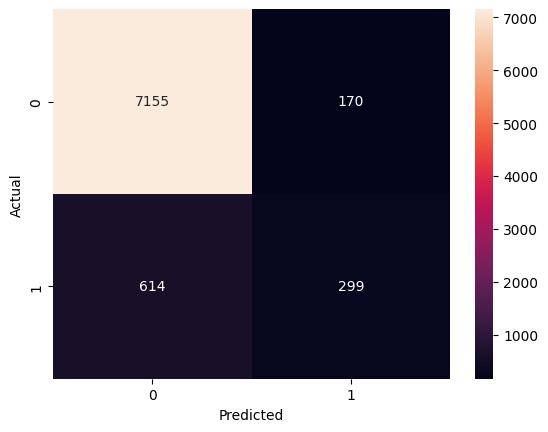

In [179]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="g")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [180]:
accuracy_score(y_test,y_pred)

0.9048312697256615

In [181]:
1-accuracy_score(y_test,y_pred)

0.09516873027433848

In [182]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7325
           1       0.64      0.33      0.43       913

    accuracy                           0.90      8238
   macro avg       0.78      0.65      0.69      8238
weighted avg       0.89      0.90      0.89      8238



Classification & Regression Trees(CART) | K – Nearest Neighbors (KNN)

In [184]:
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor

In [187]:
data=pd.read_csv("Bank.CSV")
data.head()

,age,duration,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,210,1.4,93.444,-36.1,4.963,5228.1,0
1,53,138,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,339,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,185,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,137,-2.9,92.201,-31.4,0.869,5076.2,1


In [188]:
x=data.iloc[:,:7]
y=data.iloc[:,7]

In [189]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [190]:
knnc1=KNeighborsClassifier(n_neighbors=6)

In [191]:
knnc1.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [192]:
y_pred=knnc1.predict(x_test)

In [193]:
accuracy_score(y_test,y_pred)

0.898761835396941

In [194]:
confusion_matrix(y_test,y_pred)

array([[7079,  246],
       [ 588,  325]])

In [195]:
K=range(1,11)
Errors=[]

for k in K:
    knncl=KNeighborsClassifier(n_neighbors=k)
    cvals=1-cross_val_score(knncl,x_train,y_train,cv=10,scoring="accuracy")
    Errors.append(cvals.mean())

print(Errors)

[np.float64(0.11790591805766311), np.float64(0.10631259484066766), np.float64(0.10503793626707132), np.float64(0.10191198786039454), np.float64(0.1006980273141123), np.float64(0.09860394537177543), np.float64(0.097298937784522), np.float64(0.09717754172989379), np.float64(0.09553869499241274), np.float64(0.09666160849772384)]


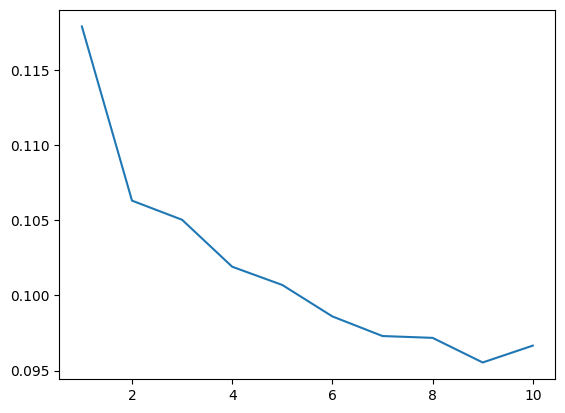

In [196]:
plt.plot(K,Errors)
plt.show()

In [197]:
knnc1=KNeighborsClassifier(n_neighbors=9)

KNeighborsRegressor

In [198]:
data=pd.read_csv("Boston.CSV")
data.head()

,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [205]:
x=data.iloc[:,:12]
y=data.iloc[:,12]

In [206]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [207]:
knnrg=KNeighborsRegressor(n_neighbors=5)

In [208]:
knnrg.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [209]:
y_pred=knnrg.predict(x_test)

In [210]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(7.1685161316280634)

Imbalance Data Handling

In [211]:
data=pd.read_csv("Bank_Imbalance.csv")
data.head()

,age,duration,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,210,1.4,93.444,-36.1,4.963,5228.1,1
1,53,138,-0.1,93.200,-42.0,4.021,5195.8,1
2,28,339,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,185,-1.8,93.075,-47.1,1.405,5099.1,1
4,55,137,-2.9,92.201,-31.4,0.869,5076.2,1


In [212]:
x=data.iloc[:,:7]
y=data.iloc[:,7]

In [213]:
y.value_counts()

y
1    2396
0     603
Name: count, dtype: int64

In [214]:
y.value_counts()/y.value_counts().sum()*100

y
1    79.893298
0    20.106702
Name: count, dtype: float64

In [216]:
from imblearn.over_sampling import SMOTE,ADASYN

In [217]:
smt=SMOTE()

In [218]:
x_sm,y_sm=smt.fit_resample(x,y)

In [219]:
y_sm.value_counts()

y
1    2396
0    2396
Name: count, dtype: int64

In [220]:
x.shape

(2999, 7)

In [221]:
x_sm.shape

(4792, 7)

In [224]:
ada=ADASYN()

In [225]:
x_ad,y_ad=ada.fit_resample(x,y)

In [226]:
y_ad.value_counts()

y
0    2403
1    2396
Name: count, dtype: int64

Hyper Parameter Optimization

In [227]:
from sklearn.model_selection import GridSearchCV,KFold

In [228]:
data=pd.read_csv("Boston.CSV")
data.head()

,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [229]:
x=data.iloc[:,:12].values
y=data.iloc[:,12].values

In [230]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [231]:
params={"n_neighbors":[1,2,3,4,5,6,7,8,9,10]}
model=KNeighborsRegressor()
cval=KFold(n_splits=10)

In [232]:
gsearch=GridSearchCV(model,params,cv=cval)

In [233]:
results=gsearch.fit(x_train,y_train)

In [234]:
results.best_params_

{'n_neighbors': 5}